In [1]:
import os
import re
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import  Counter
from wordcloud import WordCloud, STOPWORDS
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

pd.set_option("display.max_columns", None)

In [2]:
PROJECT_ROOT_DIR = "."
IMG_PATH = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(IMG_PATH, exist_ok=True)


def save_fig(fig_id, fig_extension="png", resolution=300):
    path = os.path.join(IMG_PATH, fig_id + "." + fig_extension)
    plt.tight_layout()
    print("Saving figure", fig_id)
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [3]:
df = pd.read_csv(r"dataset\processed_data\emails_processed.csv")
df.head()

,text,spam,num_chars,num_words,num_sentences
0,Subject: naturally irresistible your corporate...,1,1484,325,11
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1
2,Subject: unbelievable new homes made easy im ...,1,448,88,4
3,Subject: 4 color printing special request add...,1,500,99,5
4,"Subject: do not have money , get software cds ...",1,235,53,9


In [4]:
counts = df.spam.value_counts()
percentages = df["spam"].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nPercentages:\n", percentages)

Counts:
 spam
0    4327
1    1368
Name: count, dtype: int64

Percentages:
 spam
0    75.978929
1    24.021071
Name: proportion, dtype: float64


### Target Class Imbalance
The target variable displays a **moderate class imbalance** (~76% Non-Spam vs. ~24% Spam).

**Business/Data-Science Implication:** 
Accuracy will be a misleading metric since a naive model predicting "0" for everything would still be ~76% accurate. 

**Next Steps:**
- Plan to use metrics like **Precision, Recall, and F1-score**.
- Ensure stratified sampling is used when splitting the data into train and test sets to maintain this ratio.

In [5]:
length_stats = df.groupby("spam")[
    ["num_chars", "num_words", "num_sentences"]
].describe()

print("\nStatistics by Class:\n")
length_stats


Statistics by Class:



num_chars                                                          \
         count         mean          std   min    25%     50%      75%   
spam                                                                     
0       4327.0  1634.200139  1965.016383  13.0  577.5  1122.0  2037.50   
1       1368.0  1317.257310  2271.372893  18.0  401.5   693.5  1250.25   

              num_words                                                    \
          max     count        mean         std  min    25%    50%    75%   
spam                                                                        
0     43952.0    4327.0  347.283799  407.227757  3.0  120.0  240.0  440.5   
1     28432.0    1368.0  267.896199  451.623124  5.0   80.0  141.0  252.0   

             num_sentences                                                      
         max         count       mean        std  min  25%   50%   75%     max  
spam                                                                            
0     8479.0        4327.0  19.838225  38.124564  1.0  7.0  13.0  22.0  1565.0  
1     6131.0        1368.0  18.274123  28.130434  1.0  6.0  11.0  18.0   438.0

### Summary Statistics Analysis
The statistics reveal that on average, **spam emails are slightly shorter** than non-spam emails (~1317 vs ~1634 characters). 

**Critical Point:**
Notice the massive difference between the 75th percentile and the maximum values (e.g., max non-spam is 43,952 chars compared to a 75th percentile of 2,037). This indicates **extreme right-skewness and massive outliers** in email lengths. 


Saving figure target_count


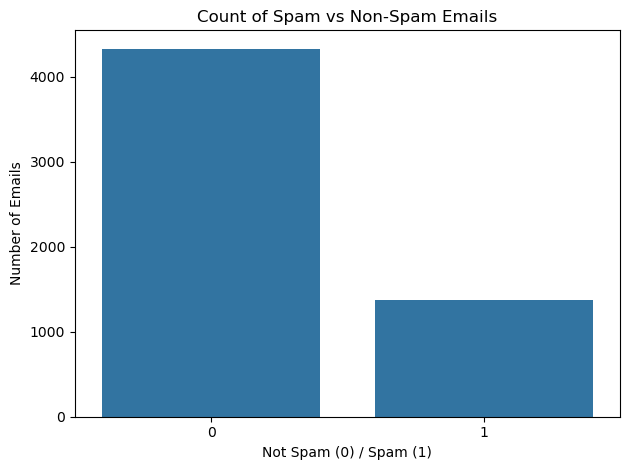

Saving figure distrbution_of_email_length


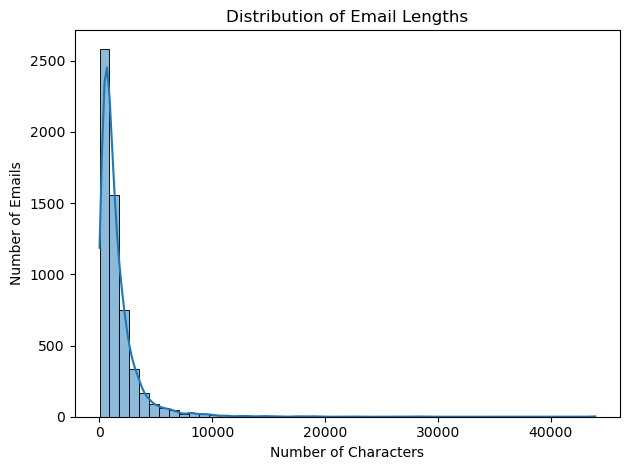

Saving figure email_len_by_class


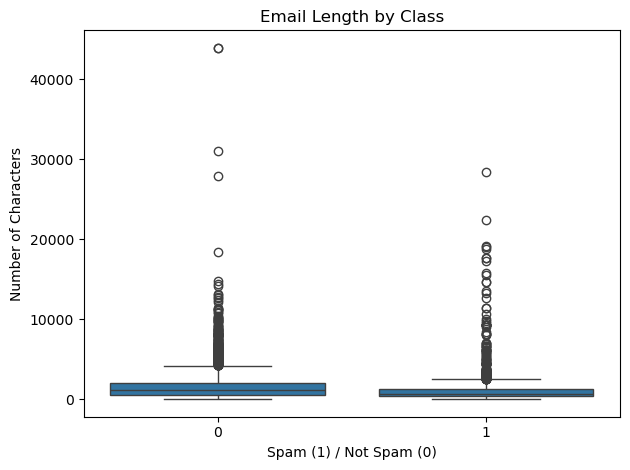

In [6]:
# 1) Bar chart: Count of spam vs non-spam
sns.countplot(x=df["spam"])
plt.title("Count of Spam vs Non-Spam Emails")
plt.xlabel("Not Spam (0) / Spam (1)")
plt.ylabel("Number of Emails")
save_fig("target_count")
plt.show()

# Histogram: Shows how email lengths are spread out
sns.histplot(df["num_chars"], bins=50, kde=True)
plt.title("Distribution of Email Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Emails")
save_fig("distrbution_of_email_length")
plt.show()

# 3) Boxplot: Email length by class
sns.boxplot(x="spam", y="num_chars", data=df)
plt.title("Email Length by Class")
plt.xlabel("Spam (1) / Not Spam (0)")
plt.ylabel("Number of Characters")
save_fig("email_len_by_class")
plt.show()

### 🔍 Insight: Visualization Limitations
The initial histograms and boxplots are highly compressed due to massive outliers (extreme right-skewness) in the text length. This makes it impossible to visually discern the distribution's core shape. 

**Data-Science Takeaway:** Whenever feature ranges vary this wildly, transformations (like log scaling) are mandatory not just for modeling, but prior to visualization. Applying the log transformation (which you correctly do in the next steps!) is an excellent logical progression.

In [7]:
df[["num_chars", "num_words", "num_sentences"]].skew()

num_chars         6.897666
num_words         6.422738
num_sentences    22.933989
dtype: float64

In [8]:
cols = ["num_chars", "num_words", "num_sentences"]

for col in cols:
    df[f"log_{col}"] = np.log1p(df[col])

Saving figure logfeat_email_by_class


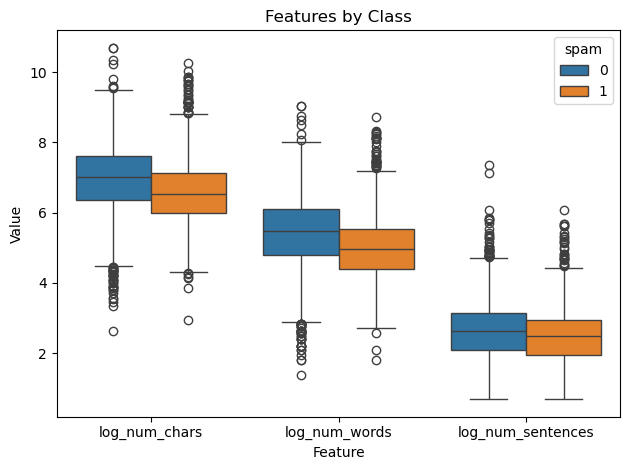

In [9]:
df_melted = df.melt(
    id_vars="spam",
    value_vars=["log_num_chars", "log_num_words", "log_num_sentences"],
    var_name="feature",
    value_name="value",
)

sns.boxplot(x="feature", y="value", hue="spam", data=df_melted)

plt.title("Features by Class")
plt.xlabel("Feature")
plt.ylabel("Value")
save_fig("logfeat_email_by_class")
plt.show()

### 🔍 Insight: Log Transformed Features
By taking the log-transform, the difference in distributions becomes mathematically well-behaved and visually apparent. We can see that standard non-spam emails tend to be slightly longer and have more sentences than spam.

**Caveat:** Despite the transformation, there is still massive overlap between the two classes. Relying strictly on length-based metadata won't reliably segregate spam from ham, necessitating deeper textual feature engineering.

Saving figure word_cloud_spam


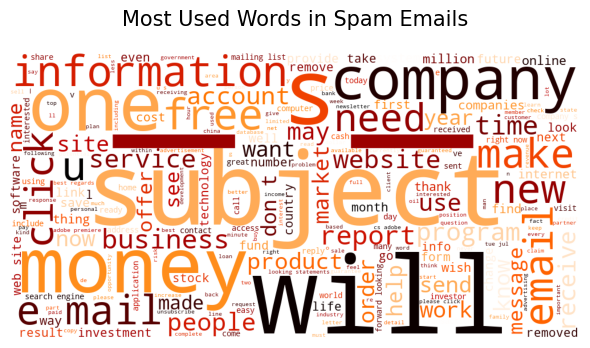

In [13]:

# check only spam emails
df_spam = df[df["spam"] == 1].copy()

# Make a big string of all words in spam emails
comment_words = ""

# Words to ignore (like 'the', 'and', 'is')
stop_words = set(STOPWORDS)

# Go through each spam email
for val in df_spam["text"]:
    val = str(val)  # make sure it is text
    tokens = val.split()  # split into separate words
    tokens = [word.lower() for word in tokens]  # make all words lowercase
    comment_words += " ".join(tokens) + " "  # add words to big string

# Make the word cloud picture
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stop_words,  # ignore common words
    min_font_size=10,
    max_words=1000,
    colormap="gist_heat_r",
).generate(comment_words)

# Show the word cloud
plt.figure(figsize=(6, 6))
plt.title("Most Used Words in Spam Emails", fontsize=15, pad=20)
plt.imshow(wordcloud)  # show image
plt.axis("off")  # hide axes
plt.tight_layout(pad=0)
save_fig("word_cloud_spam")
plt.show()

Saving figure word_cloud_ham


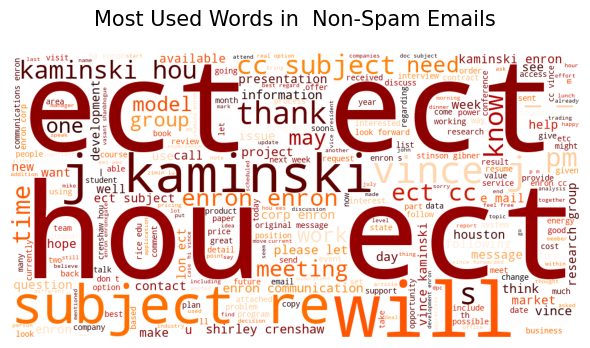

In [14]:
# --- WordCloud for Most Used Words in Spam Emails ---
from wordcloud import WordCloud, STOPWORDS

# check only spam emails
df_not_spam = df[df["spam"] == 0].copy()

# Make a big string of all words in spam emails
comment_words = ""

# Words to ignore (like 'the', 'and', 'is')
stop_words = set(STOPWORDS)

# Go through each spam email
for val in df_not_spam["text"]:
    val = str(val)  # make sure it is text
    tokens = val.split()  # split into separate words
    tokens = [word.lower() for word in tokens]  # make all words lowercase
    comment_words += " ".join(tokens) + " "  # add words to big string

# Make the word cloud picture
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stop_words,  # ignore common words
    min_font_size=10,
    max_words=1000,
    colormap="gist_heat_r",
).generate(comment_words)

# Show the word cloud
plt.figure(figsize=(6, 6))
plt.title("Most Used Words in  Non-Spam Emails", fontsize=15, pad=20)
plt.imshow(wordcloud)  # show image
plt.axis("off")  # hide axes
plt.tight_layout(pad=0)
save_fig("word_cloud_ham")

plt.show()

In [15]:
spam_words = Counter(" ".join(df[df["spam"] == 1]["text"]).split())
spam_words.most_common(20)

[('.', 19839),
 ('_', 13556),
 (',', 11514),
 ('the', 8975),
 ('-', 8514),
 ('to', 8165),
 ('and', 6517),
 ('of', 5629),
 ('you', 4920),
 ('a', 4695),
 (':', 4691),
 ('in', 3879),
 ('your', 3730),
 ('!', 3310),
 ('for', 3186),
 ('is', 2977),
 ('this', 2822),
 ('/', 2578),
 ("'", 2326),
 ('$', 2242)]

### ⚠️ Critique: Uncleaned Word Frequencies
Looking at the `Counter` output, the top "words" are actually punctuation marks (`.`, `_`, `,`) and generic English stopwords (`the`, `to`, `and`). 

**Data-Science Meaning:** High frequency doesn't equal high information. Term frequencies based on uncleaned text yield zero discriminative value for predictive models. Furthermore, `WordCloud` internally removes punctuation and stopwords, which masks the true messy state of the underlying data. It's crucial that we apply hard transformations to the actual text string, as you do in the next cells.

In [16]:
stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = word_tokenize(text)
    filtered = [
        word for word in words if word.isalnum() and word.lower() not in stop_words
    ]
    return " ".join(filtered)

df["text_clean"] = df["text"].apply(remove_stopwords)

In [17]:
print("Original:", df["text"].iloc[0])
print("Cleaned :", df["text_clean"].iloc[0])

Original: Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability :

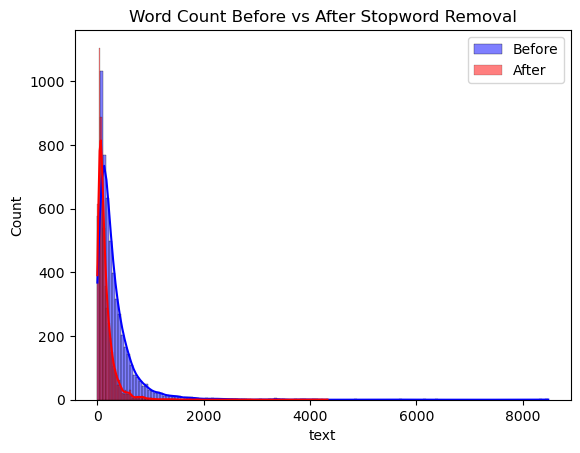

In [18]:
num_words_before = df["text"].apply(lambda x: len(word_tokenize(x)))
num_words_after = df["text_clean"].apply(lambda x: len(word_tokenize(x)))

sns.histplot(x = num_words_before, color="blue", label="Before", kde=True)
sns.histplot(x = num_words_after, color="red", label="After", kde=True)

plt.legend()
plt.title("Word Count Before vs After Stopword Removal")
plt.show()

In [19]:
spam_words = Counter(" ".join(df[df["spam"] == 1]["text_clean"]).split())
spam_words.most_common(20)

[('Subject', 1368),
 ('com', 999),
 ('1', 952),
 ('business', 844),
 ('company', 805),
 ('email', 804),
 ('information', 740),
 ('e', 701),
 ('5', 687),
 ('money', 662),
 ('2', 613),
 ('free', 606),
 ('3', 604),
 ('http', 600),
 ('get', 590),
 ('mail', 586),
 ('one', 581),
 ('please', 581),
 ('000', 560),
 ('us', 537)]

In [20]:
non_spam_words = Counter(" ".join(df[df["spam"] == 0]["text_clean"]).split())
non_spam_words.most_common(20)

[('enron', 13329),
 ('ect', 11410),
 ('vince', 8468),
 ('hou', 5567),
 ('2000', 4932),
 ('kaminski', 4723),
 ('com', 4397),
 ('please', 4332),
 ('Subject', 4327),
 ('subject', 4218),
 ('would', 4124),
 ('cc', 3862),
 ('j', 3669),
 ('pm', 3247),
 ('2001', 3021),
 ('research', 2635),
 ('thanks', 2509),
 ('1', 2471),
 ('2', 2295),
 ('know', 2281)]

### 🚨 CRITICAL FLAW: Severe Dataset Bias & Leakage
The top words for our non-spam class are heavily dominated by entity-specific names: **'enron', 'ect', 'vince', 'kaminski', 'hou'**. 

**Business/Model Implication:** This is a classic case of **Data Leakage / Dataset Bias** known to the Enron-Spam dataset. The model will essentially learn a rule: *"If the email is addressed to Vince Kaminski, it is not spam."* It will completely fail to generalize to any other user's inbox in the real world. 

**Recommended Next Step:** Treat these specific terms as domain-specific stopwords and aggressively strip them from the corpus so the model is forced to learn general linguistic patterns of normal business emails instead of memorizing Enron company names.

In [31]:
exclude_words = {"enron", "ect", "vince", "kaminski", "hou"}

for word in exclude_words:
    non_spam_words.pop(word, None)

non_spam_words.most_common(20)

[('2000', 4932),
 ('com', 4397),
 ('please', 4332),
 ('Subject', 4327),
 ('subject', 4218),
 ('would', 4124),
 ('cc', 3862),
 ('j', 3669),
 ('pm', 3247),
 ('2001', 3021),
 ('research', 2635),
 ('thanks', 2509),
 ('1', 2471),
 ('2', 2295),
 ('know', 2281),
 ('group', 2235),
 ('10', 2206),
 ('time', 2197),
 ('energy', 2103),
 ('risk', 1980)]

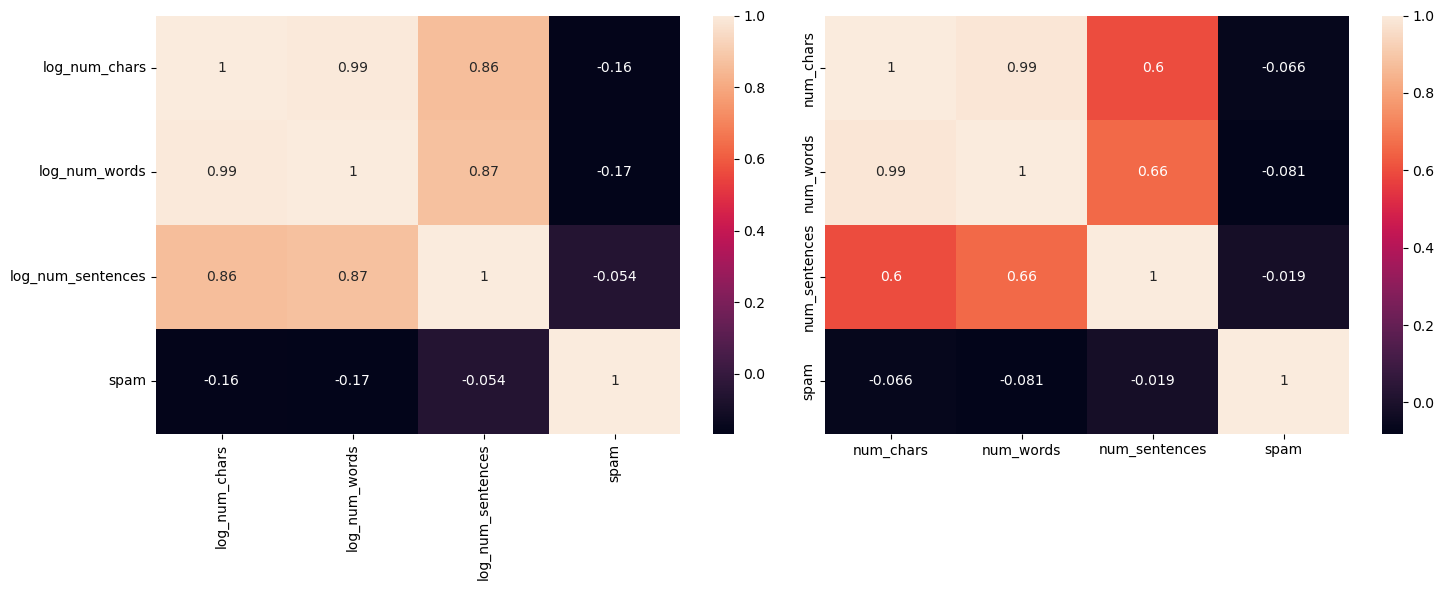

In [21]:
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
sns.heatmap(
    df[["log_num_chars", "log_num_words", "log_num_sentences", "spam"]].corr(), annot=True
)
plt.subplot(1, 2, 2)
sns.heatmap(
    df[["num_chars", "num_words", "num_sentences", "spam"]].corr(), annot=True
)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

spam_text = df[df['spam'] == 1]['text']

cv = CountVectorizer(ngram_range=(2,2), stop_words='english')
X_spam = cv.fit_transform(spam_text)

spam_ngrams = pd.DataFrame({
    "ngram": cv.get_feature_names_out(),
    "count": X_spam.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

spam_ngrams.head(10)

,ngram,count
36249,http www,306
40629,jul 2005,159
1718,19 jul,154
31001,forward looking,112
45474,mailing list,112
66154,search engines,111
26175,email address,110
72550,submit website,103
2140,2005 10,102
44523,looking statements,101


In [ ]:
ham_text = df[df["spam"] == 0]["text"]

cv = CountVectorizer(ngram_range=(2, 2), stop_words="english")
X_ham = cv.fit_transform(ham_text)

ham_ngrams = pd.DataFrame(
    {"ngram": cv.get_feature_names_out(), "count": X_ham.toarray().sum(axis=0)}
).sort_values(by="count", ascending=False)
 
ham_ngrams.head(10)

,ngram,count
110785,hou ect,5225
76878,ect ect,4879
243418,vince kaminski,4070
82406,enron com,2216
42205,cc subject,2042
126027,kaminski hou,1776
76817,ect cc,1582
82603,enron enron,1553
131402,let know,1504
208450,shirley crenshaw,1042


Saving figure top_spam_bigrams


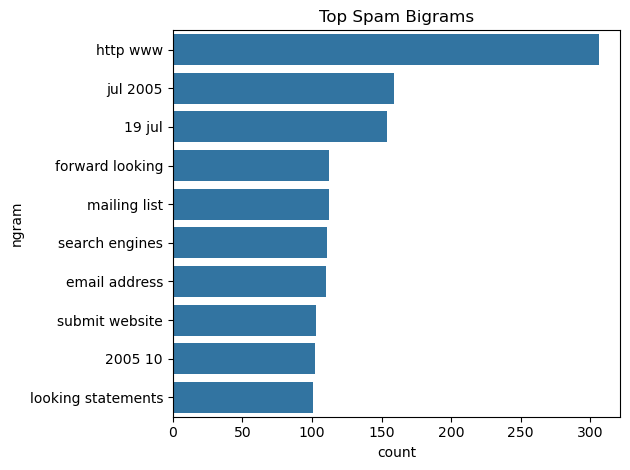

In [24]:
top = spam_ngrams.head(10)

sns.barplot(x="count", y="ngram", data=top)

plt.title("Top Spam Bigrams")
save_fig("top_spam_bigrams")
plt.show()

### ⚠️ Critique: Era-Specific Noise in N-Grams
Beyond the 'vince kaminski' leakage in the ham dataset, notice that one of the top spam bigrams is **'jul 2005'**. 

**Weak Conclusion:** While this works perfectly for this specific dataset and era, deploying this model in modern times would degrade its performance. It's overfitting to the temporal distribution of the spam campaign. We must reconsider using raw standard CountVectorizers and explore TF-IDF (Term Frequency-Inverse Document Frequency) down-weighting, or regex scrubbing of dates.

In [25]:
df.head()

,text,spam,num_chars,num_words,num_sentences,log_num_chars,log_num_words,log_num_sentences,text_clean
0,Subject: naturally irresistible your corporate...,1,1484,325,11,7.303170,5.786897,2.484907,Subject naturally irresistible corporate ident...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,6.395262,4.510860,0.693147,Subject stock trading gunslinger fanny merrill...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,6.107023,4.488636,1.609438,Subject unbelievable new homes made easy im wa...
3,Subject: 4 color printing special request add...,1,500,99,5,6.216606,4.605170,1.791759,Subject 4 color printing special request addit...
4,"Subject: do not have money , get software cds ...",1,235,53,9,5.463832,3.988984,2.302585,Subject money get software cds software compat...


In [26]:
df["num_caps"] = df["text"].apply(lambda x: sum(1 for c in x if c.isupper()))
df["num_digits"] = df["text"].apply(lambda x: sum(1 for c in x if c.isdigit()))
df["num_special"] = df["text"].apply(
    lambda x: sum(1 for c in x if c in string.punctuation)
)
df["has_link"] = df["text"].apply(lambda x: 1 if re.search(r"http|www|\.com", x) else 0)
df["has_phone"] = df["text"].apply(lambda x: 1 if re.search(r"\d{10}", x) else 0)
df["caps_ratio"] = df["num_caps"] / (df["num_chars"] + 1)
df["num_exclamations"] = df["text"].apply(lambda x: x.count("!"))
df["num_questions"] = df["text"].apply(lambda x: x.count("?"))

In [27]:
df.groupby("spam")[
    ["num_caps", "num_digits", "num_special", "has_link", "has_phone"]
].mean()

,num_caps,num_digits,num_special,has_link,has_phone
spam,,,,,
0,1.0,41.418304,91.785302,0.164317,0.016871
1,1.0,24.644006,60.679825,0.315789,0.015351


### 🚨 CRITICAL ERROR: Broken Engineered Feature (`num_caps`)
Notice that the mean of `num_caps` is exactly **1.000000** for both classes. 

**Diagnostic:** This logically implies that virtually every single email in the dataset was pre-lowercased before you even loaded it *except for exactly one letter* (almost certainly the 'S' in 'Subject:'). 
**Impact:** Because the original source capitalization was destroyed before this EDA, `num_caps` and `caps_ratio` are dead constant features containing absolutely zero predictive power. Capitalization is typically an amazing predictor for spam, but unfortunately, we cannot use it on this pre-processed dataset.

In [28]:
# Get important features using Lasso

features = [
    "num_chars",
    "num_words",
    "num_sentences",
    "num_caps",
    "num_digits",
    "num_special",
    "has_link",
    "has_phone",
    "caps_ratio",
    "num_exclamations",
    "num_questions",
]

X = df[features]
y = df["spam"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LassoCV(cv=5) 
model.fit(X_scaled, y)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [29]:
importance = pd.Series(model.coef_, index=features)
importance = importance.sort_values(ascending=False)

print(importance)

num_exclamations    0.136104
has_link            0.063389
num_sentences       0.043727
caps_ratio          0.027343
has_phone           0.000132
num_caps            0.000000
num_chars           0.000000
num_questions      -0.015974
num_words          -0.023508
num_digits         -0.028534
num_special        -0.070581
dtype: float64


Saving figure lasso_feat_imp


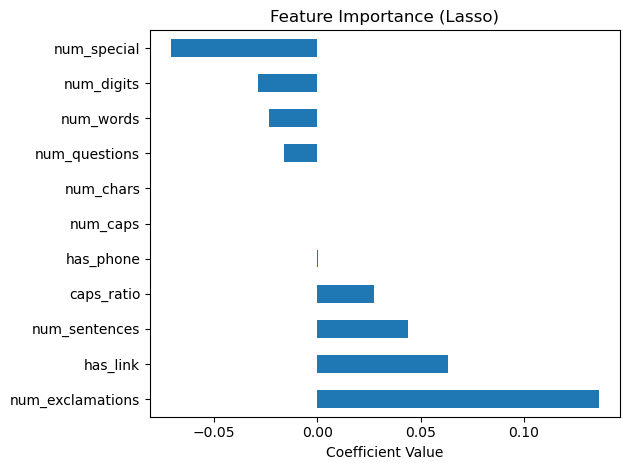

In [30]:
importance.plot(kind="barh")
plt.title("Feature Importance (Lasso)")
plt.xlabel("Coefficient Value")
save_fig("lasso_feat_imp")
plt.show()

Lasso regression highlights that features like the number of exclamation marks, presence of links, and uppercase ratio are strong predictors of spam. 

Interestingly, some features such as total number of characters and number of capital letters were reduced to zero, indicating redundancy with other features.

Certain features like number of special characters and digits show negative coefficients, which may be due to multicollinearity. Lasso tends to select one representative feature among correlated ones, causing others to be suppressed or assigned negative weights.

Overall, punctuation intensity and presence of links appear to be the most distinguishing characteristics of spam messages in this dataset.

### 🧠 Senior Data Scientist Review & Next Steps
The flow of this EDA is generally very strong. You systematically went from target imbalance, to metadata (length), to lexicon (words), to engineered linguistic features. However, there are significant flaws regarding how data anomalies are interpreted.

**Corrections to the Lasso Conclusion:**
1. Lasso didn't reduce the coefficient for `num_caps` to zero because capitalization isn't inherently useful for spam detection—it reduced it to zero because the `num_caps` feature is practically a constant (mean=1) due to early lowercase processing in the dataset!
2. Total `num_chars` was likely dropped because it's perfectly collinear with `num_words`, and Lasso naturally selects only one of highly correlated features and shrinks the others.

**Actionable Next Steps for Modeling:**
- **Address Leakage immediately:** Remove 'enron'-specific domain entities from the vocabulary. 
- **Remove Dead Features:** Drop `num_caps` and `caps_ratio`.
- **Feature Extraction:** Transition from basic `CountVectorizer` to `TfidfVectorizer` to naturally down-weight common terms. 
- **Advanced Modeling:** Combine the TF-IDF sparse matrices with your robust engineered dense features (like `has_link`, `log_num_words`) into a unified machine learning pipeline (like Random Forest or XGBoost).